# Notebook 1: Simulating the Physical Twin with Real Weather & Libraries 🌦️🔋
**Supported by the WEL Research Institute (WEL-T) - EDITS Project**

In the five-layer architecture of an intelligent Digital Twin, **Layer 1 (Data Generation & Ingestion)** acts as the sensory nervous system . Instead of relying on static, simulated weather patterns, a true Digital Twin dynamically links to live environments.

In this notebook, we will:
1. Connect to the free, non-authenticated **Open-Meteo API** to pull a 7-day hourly forecast for any location on Earth.
2. Use **`pvlib`** (a premier solar physics library) to simulate a physical photovoltaic inverter system under real atmospheric conditions .
3. Use **`windpowerlib`** (a standard wind energy library) to compute wind generation using a real turbine power curve .

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Solar imports
import pvlib
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.modelchain import ModelChain as PVModelChain

# Wind imports
from windpowerlib import ModelChain as WindModelChain
from windpowerlib import WindTurbine

from datetime import date, timedelta


In [2]:
# ==========================================
# 🛠️ YOUR TURN: Choose coordinates to test!
# Default: Brussels, Belgium (Latitude: 50.85, Longitude: 4.35)
# Try Madrid, Spain: Lat: 40.41, Lon: -3.70
# Try Reykjavik, Iceland: Lat: 64.14, Lon: -21.94
LATITUDE = 50.85
LONGITUDE = 4.35
LOCATION_NAME = "Brussels, Belgium"
# ==========================================

print(f"Connecting to Open-Meteo to fetch live forecast for: {LOCATION_NAME}...")

Connecting to Open-Meteo to fetch live forecast for: Brussels, Belgium...


## Step 1.1: Fetching Real-World Weather from Open-Meteo API

[Open-Meteo](https://open-meteo.com/) is a free, open-source weather API designed for non-commercial use. It aggregates meteorological data from various national weather services and scientific institutions to provide highly accurate, global weather forecasts and historical climate data.

### Key Features

* **No API Key Required:** You can start making requests immediately for development, testing, and personal projects without registering or managing API keys.
* **Global Coverage:** It utilizes various high-resolution numerical weather prediction models (such as ECMWF IFS, NOAA GFS, DWD ICON, and Météo-France AROME) to deliver global forecasts.
* **Hourly & Daily Forecasts:** Provides detailed hourly parameters (temperature, precipitation, wind speed, relative humidity, cloud cover, etc.) and daily summaries.
* **Historical Weather Data:** Offers access to historical climate data dating back to 1940 through the ERA5 reanalysis dataset.
* **Specialized Endpoints:** Includes dedicated APIs for:
  * **Geocoding:** Resolving city names to coordinates.
  * **Air Quality:** Forecasting PM2.5, PM10, ozone, and nitrogen dioxide levels.
  * **Marine/Ocean:** Ocean wave height, direction, and period.
  * **Elevation:** Retrieving topographic elevation for coordinates.


### What do we need? 
*   **`temperature_2m`**: The air temperature measured at 2 meters above the ground (the standard meteorological measurement height).
*   **`wind_speed_10m`**: Wind speed at 10 meters above the ground (used for standard weather observations).
*   **`wind_speed_100m`**: Wind speed at 100 meters above the ground. This is a critical metric for wind energy modeling, as the hub height of modern commercial wind turbines is typically located around this level.

*   **`shortwave_radiation`**: Also known as **Global Horizontal Irradiance (GHI)**. This is the total solar radiation reaching a horizontal surface on Earth, representing the sum of direct and diffuse solar radiation.
*   **`diffuse_radiation`**: Also known as **Diffuse Horizontal Irradiance (DHI)**. This measures the solar radiation that has been scattered or refracted by atmospheric molecules, clouds, and aerosols, reaching a horizontal surface (it excludes the direct solar beam).
*   **`direct_normal_irradiance`**: Also known as **Direct Normal Irradiance (DNI)**. This represents the direct solar radiation received per unit area on a surface kept perpendicular (normal) to the incoming rays of the sun. This parameter is highly important for tracking solar panels.

![Solar Scheme](assets/solar.png)


In [3]:
end_date_obj = date.today() - timedelta(days=1)   # One day ago
start_date_obj = end_date_obj - timedelta(days=30) # 30 days prior

START_DATE = start_date_obj.strftime("%Y-%m-%d")
END_DATE = end_date_obj.strftime("%Y-%m-%d")

print(f"Targeting Training Window: {START_DATE} to {END_DATE} (~720 hourly samples)")

# ==========================================================
# 🌐 API Call to Open-Meteo Archive
# ==========================================================
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": "temperature_2m,wind_speed_10m,wind_speed_100m,shortwave_radiation,diffuse_radiation,direct_normal_irradiance",
    "timezone": "UTC"
}

response = requests.get(url, params=params)
data = response.json()

Targeting Training Window: 2026-05-14 to 2026-06-13 (~720 hourly samples)


In [4]:
# We can take a look at the structure of the data to understand what we received
print("Data keys:", data.keys())

Data keys: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [5]:
# 2. Extract and format into a Pandas DataFrame
hourly_data = data["hourly"]
time_idx = pd.to_datetime(hourly_data["time"])

# Build the DataFrame with the raw lists first
synthetic_df = pd.DataFrame({
    "temp_air": hourly_data["temperature_2m"],          # Air temperature (C)
    "wind_speed": hourly_data["wind_speed_10m"],        # As km/h for now, will convert to m/s later
    "wind_speed_100m": hourly_data["wind_speed_100m"],  # As km/h for now, will convert to m/s later
    "ghi": hourly_data["shortwave_radiation"],          # Global Horizontal Irradiance (W/m2)
    "dhi": hourly_data["diffuse_radiation"],            # Diffuse Horizontal Irradiance (W/m2)
    "dni": hourly_data["direct_normal_irradiance"]      # Direct Normal Irradiance (W/m2)
}, index=time_idx)

# 3. Perform vector operations safely on the Pandas Series (convert km/h to m/s)
synthetic_df["wind_speed"] = synthetic_df["wind_speed"] / 3.6
synthetic_df["wind_speed_100m"] = synthetic_df["wind_speed_100m"] / 3.6

print("Weather data successfully ingested from live API!")
print(synthetic_df.head())

Weather data successfully ingested from live API!
                     temp_air  wind_speed  wind_speed_100m  ghi  dhi  dni
2026-05-14 00:00:00       6.4    3.888889         7.055556  0.0  0.0  0.0
2026-05-14 01:00:00       6.4    3.944444         7.138889  0.0  0.0  0.0
2026-05-14 02:00:00       5.8    3.944444         7.250000  0.0  0.0  0.0
2026-05-14 03:00:00       5.8    3.750000         6.916667  0.0  0.0  0.0
2026-05-14 04:00:00       5.4    3.777778         6.944444  0.0  0.0  0.0


Text(0.5, 0.98, 'Weather Data Time Series (Last 30 Days)')

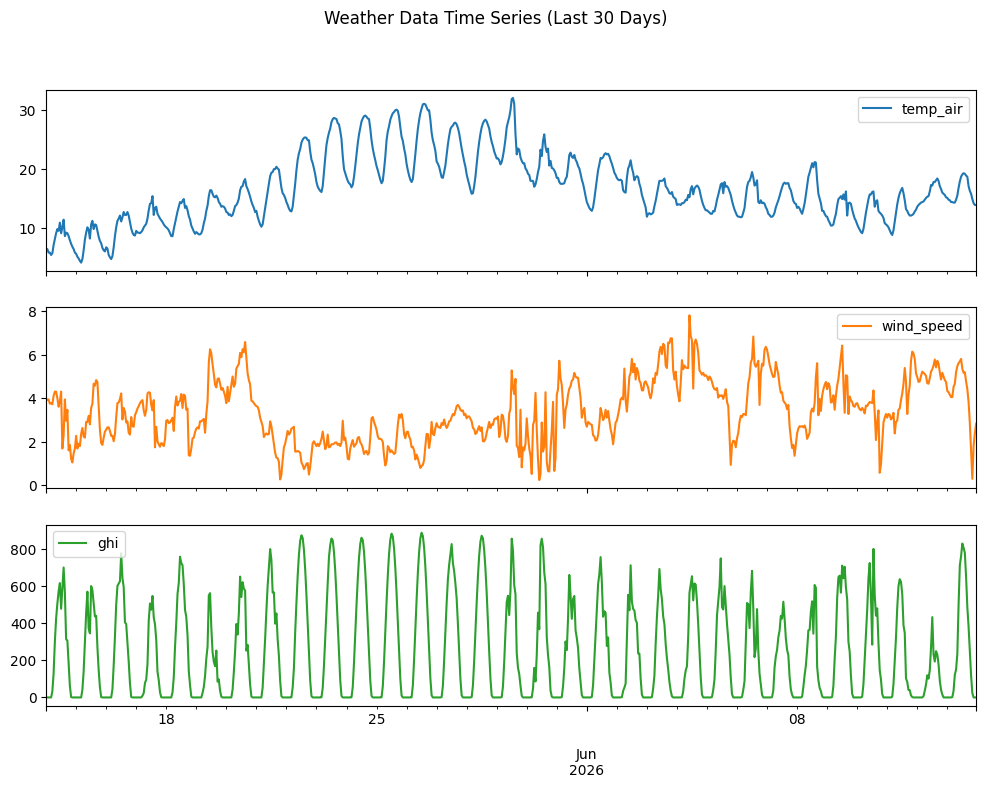

In [6]:
# plot the data to visualize
synthetic_df[["temp_air", "wind_speed", "ghi"]].plot(subplots=True, figsize=(12, 8))
plt.suptitle("Weather Data Time Series (Last 30 Days)")

### Step 1.2: Simulating Solar Output with `pvlib`
Here we set up a simulated physical array. We define fixed physical properties (tilt, panel orientation, and heat-loss temperature coefficients) and model how they interact with real sunlight .

In [7]:
# 1. Define Location details
site = Location(LATITUDE, LONGITUDE, tz="UTC")

# 2. Define the physical system (250W module, south-facing, 30-degree tilt)
module_parameters = {
    "pdc0": 250,          # Power at Standard Test Conditions (W)
    "gamma_pdc": -0.0045, # Temperature derating coefficient (power drops as panel heats up)
}

inverter_parameters = {
    "pdc0": 240,          # Inverter max AC power output (W)
    "eta_inv_nom": 0.96,  # 96% efficient
}

system = PVSystem(
    surface_tilt=30,      # Angle to the horizontal plane
    surface_azimuth=180,  # South-facing
    module_parameters=module_parameters,
    inverter_parameters=inverter_parameters,
    racking_model="open_rack",
    module_type="glass_polymer"
)

# 3. Instantiate the Model Chain and simulate
# pvlib requires specifically named columns: 'ghi', 'dni', 'dhi', 'temp_air', 'wind_speed'
solar_mc = PVModelChain(system, site, aoi_model="physical", spectral_model="no_loss")
solar_mc.run_model(synthetic_df)

# Store simulated AC output (converted to kW for scaling)
synthetic_df["Solar_kW"] = (solar_mc.results.ac * 100) / 1000  # Scaling up to a 100-panel array
synthetic_df["Solar_kW"] = np.maximum(0, synthetic_df["Solar_kW"])

print("Physics-based Solar Simulation complete!")

Physics-based Solar Simulation complete!


Text(0.5, 1.0, 'Simulated Solar Power Output (kW) - 100 Panel Array')

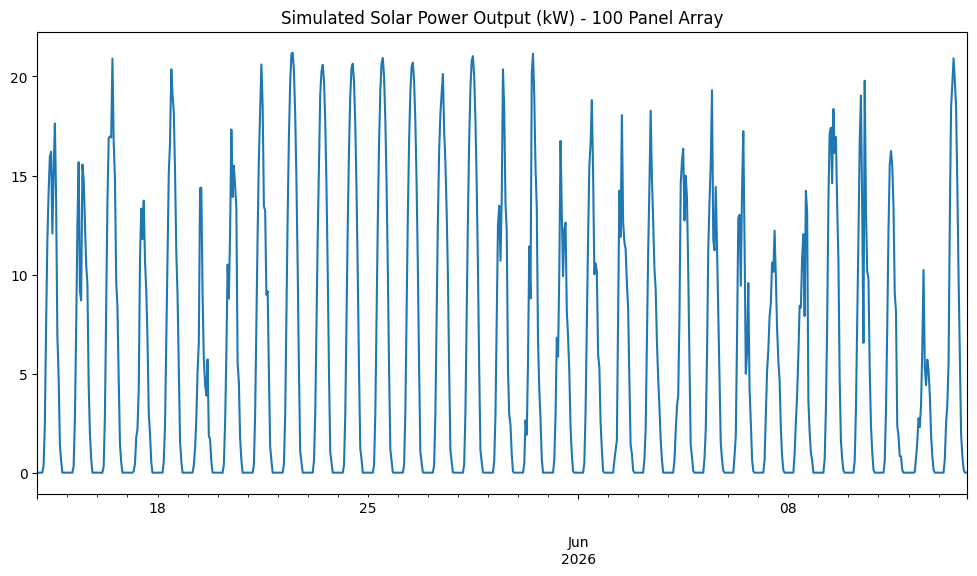

In [8]:
# Plot the simulated solar power output
synthetic_df["Solar_kW"].plot(figsize=(12, 6))
plt.title("Simulated Solar Power Output (kW) - 100 Panel Array")

### Step 1.3: Simulating Wind Output with `windpowerlib`

Wind turbines are heavily non-linear. They don't generate power at low wind speeds, reach maximum capacity at rated speeds, and safely shut down in high storms . We model this non-linear behavior by defining a standard power curve .

In [9]:
# 1. Define the Wind Turbine specifications
# We create a 100-meter hub height turbine with a standard power curve
power_curve = pd.DataFrame({
    "wind_speed": [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 25],
    "value": [0.0, 0.0, 10.0, 50.0, 100.0, 300.0, 700.0, 1200.0, 2000.0,
             2500.0, 3000.0, 3050.0, 3050.0, 3050.0, 3050.0, 3050.0, 2500.0, 0.0], # Power output in kW
})

turbine_spec = {
    "turbine_type": "custom_turbine",
    "hub_height": 100,  # Height of the turbine hub in meters
    "power_curve": power_curve,
}

turbine = WindTurbine(**turbine_spec)

# 2. Format weather columns specifically for windpowerlib's MultiIndex expectations
wind_weather = synthetic_df[['wind_speed_100m', 'temp_air']].copy()
wind_weather.columns = [
    ('wind_speed', 100), 
    ('temperature', 2)
]
wind_weather.columns = pd.MultiIndex.from_tuples(wind_weather.columns)

# 3. Simulate wind turbine output
wind_mc = WindModelChain(turbine)
wind_mc.run_model(wind_weather)

# Store turbine output in our main DataFrame
synthetic_df["Wind_kW"] = wind_mc.power_output / 1000 # Convert Watts to kW
print("Physics-based Wind Simulation complete!")

Physics-based Wind Simulation complete!


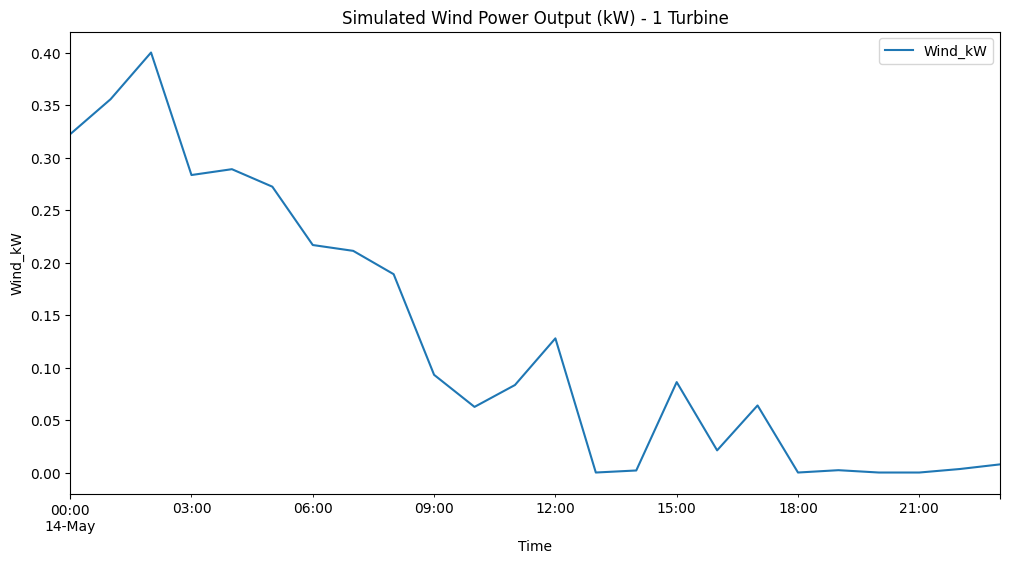

In [10]:
# Plot one day only
one_day = synthetic_df.loc[START_DATE, ["Wind_kW"]]
one_day.plot(figsize=(12, 6))
plt.title("Simulated Wind Power Output (kW) - 1 Turbine")
plt.xlabel("Time")
plt.ylabel("Wind_kW")
plt.show()

### Step 1.4, consumption
This block models community electricity demand using a standard double-peak (diurnal) distribution—with a smaller peak in the morning and a larger peak in the evening. It also factors in a slight reduction in base consumption during weekends and adds random noise to simulate unpredictable real-world usage.

In [11]:
np.random.seed(42)  # Set seed for reproducible synthetic noise

hours = synthetic_df.index.hour
is_weekend = synthetic_df.index.dayofweek >= 5

# 📉 SCALED DOWN: Define a lower baseline load (e.g., 5 kW on weekends, 7 kW on weekdays)
base_demand = np.where(is_weekend, 5.0, 7.0)

# 📉 SCALED DOWN: Simulate morning peak (+10 kW instead of +45 kW)
morning_peak = 10.0 * np.exp(-((hours - 8.5) / 1.5) ** 2)

# 📉 SCALED DOWN: Simulate evening peak (+20 kW instead of +85 kW)
evening_peak = 20.0 * np.exp(-((hours - 19.5) / 2.5) ** 2)

# 📉 SCALED DOWN: Add minor random hourly variations (reduced noise scale)
noise = np.random.normal(0, 2.0, len(synthetic_df))

# Compute the total community consumption profile (Demand in kW)
synthetic_df["Demand_kW"] = base_demand + morning_peak + evening_peak + noise

# Bound demand to ensure it never falls below a logical base load floor (e.g., 2 kW)
synthetic_df["Demand_kW"] = np.maximum(2.0, synthetic_df["Demand_kW"])

print("Scaled-down community consumption simulation complete!")
print(synthetic_df[["Demand_kW"]].head())

Scaled-down community consumption simulation complete!
                     Demand_kW
2026-05-14 00:00:00   7.993428
2026-05-14 01:00:00   6.723471
2026-05-14 02:00:00   8.295377
2026-05-14 03:00:00  10.046074
2026-05-14 04:00:00   6.532927


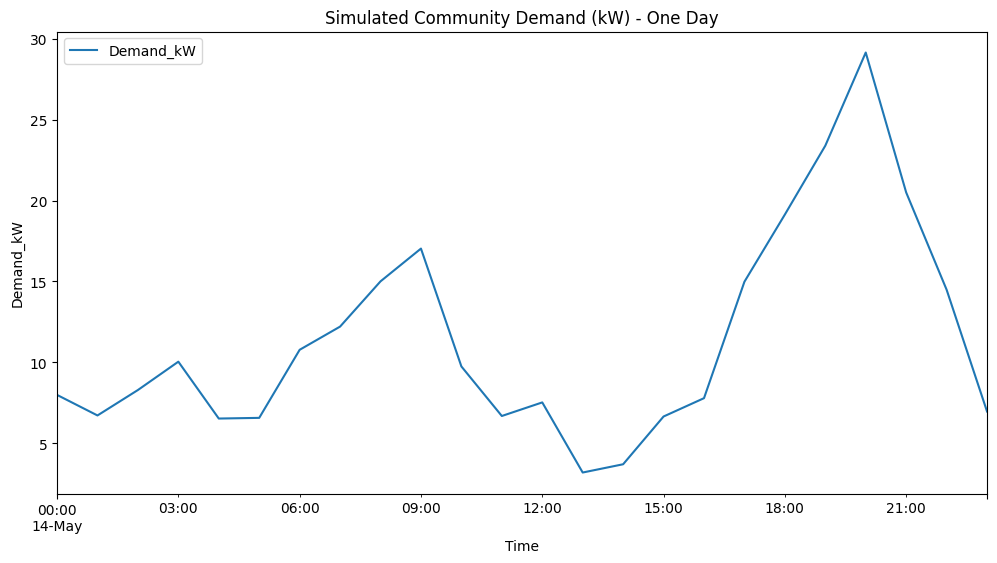

In [12]:
# Plot one day only
one_day = synthetic_df.loc[START_DATE, ["Demand_kW"]]
one_day.plot(figsize=(12, 6))
plt.title("Simulated Community Demand (kW) - One Day")
plt.xlabel("Time")
plt.ylabel("Demand_kW")
plt.show()

### Step 1.5: energy cost
This section models dynamic Time-of-Use (ToU) electricity pricing. It introduces a "duck curve" discount: when simulated solar generation is high relative to its peak, energy prices in the market drop due to high renewable penetration.

In [13]:
# %%
# ==========================================================
# 💶 Step 1.5: Simulating Dynamic Energy Tariffs (Duck Curve)
# ==========================================================

# Base import/market electricity cost (e.g., €0.15 per kWh)
base_price = 0.15

# Apply a price premium during peak demand hours (08:00-10:00 and 17:00-21:00)
peak_premium = np.where((hours >= 8) & (hours <= 10) | (hours >= 17) & (hours <= 21), 0.12, 0.0)

# Duck curve effect: deduct up to €0.06/kWh when local solar generation is abundant
max_solar = synthetic_df["Solar_kW"].max()
solar_damping = 0.06 * (synthetic_df["Solar_kW"] / max_solar if max_solar > 0 else 0)

# Combine elements and add minor market price volatility
price_volatility = np.random.uniform(-0.015, 0.015, len(synthetic_df))
synthetic_df["Price_EUR_per_kWh"] = base_price + peak_premium - solar_damping + price_volatility

# Keep prices within realistic boundaries (e.g., €0.05 to €0.45 per kWh)
synthetic_df["Price_EUR_per_kWh"] = np.clip(synthetic_df["Price_EUR_per_kWh"], 0.05, 0.45)

print("Dynamic energy pricing simulation complete!")
print(synthetic_df[["Price_EUR_per_kWh"]].head())

Dynamic energy pricing simulation complete!
                     Price_EUR_per_kWh
2026-05-14 00:00:00           0.139989
2026-05-14 01:00:00           0.157141
2026-05-14 02:00:00           0.137484
2026-05-14 03:00:00           0.153095
2026-05-14 04:00:00           0.142360


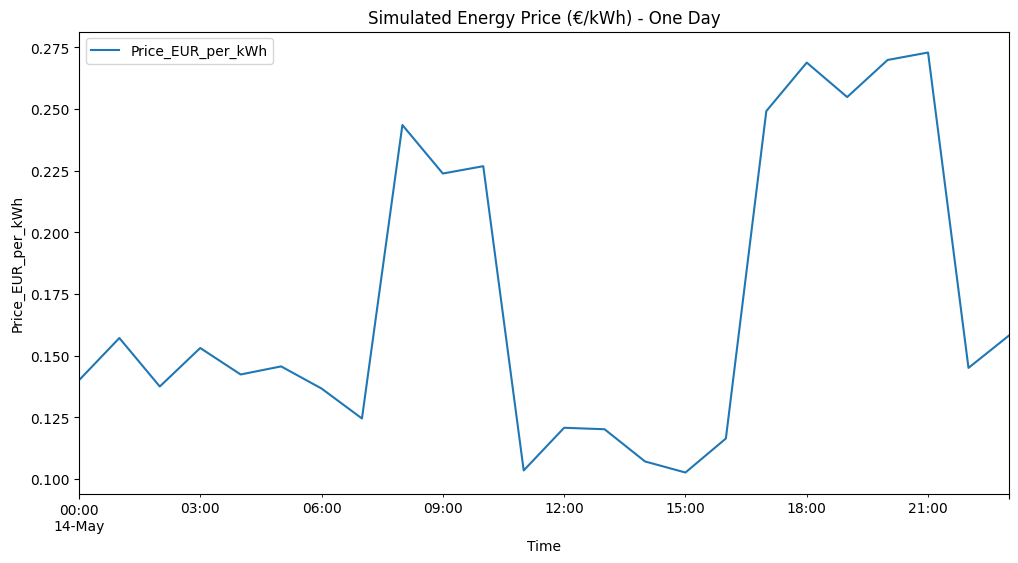

In [14]:
# Plot one day only
one_day = synthetic_df.loc[START_DATE, ["Price_EUR_per_kWh"]]
one_day.plot(figsize=(12, 6))
plt.title("Simulated Energy Price (€/kWh) - One Day")
plt.xlabel("Time")
plt.ylabel("Price_EUR_per_kWh")
plt.show()

### Step 1.7, train/test split
Since time-series data is sequential and contains temporal dependencies (such as daily patterns and seasonal trends), standard random splitting (using shuffle) is avoided as it introduces data leakage. Instead, this block performs a chronological split, allocating the first 80% of the timeline to training and the final 20% to testing.

In [15]:
# Total data points
total_samples = len(synthetic_df)
train_size = int(total_samples * 0.8)

# Slice the data sequentially to preserve temporal features
train_df = synthetic_df.iloc[:train_size].copy()
test_df = synthetic_df.iloc[train_size:].copy()


train_df.to_csv("synthetic_df_train.csv")
test_df.to_csv("synthetic_df_test.csv")

In [16]:
train_df.columns

Index(['temp_air', 'wind_speed', 'wind_speed_100m', 'ghi', 'dhi', 'dni',
       'Solar_kW', 'Wind_kW', 'Demand_kW', 'Price_EUR_per_kWh'],
      dtype='object')

1. Compare the combined generation graph of Brussels vs. Madrid. Which location has more stable, complementary energy profiles (solar peaks offsetting wind drops)?
2. Observe how the temperature derating works in sunny locations: did a spike in Spain's temperature during the afternoon cause a dip in solar efficiency?
3. How does the wind turbine's non-linear curve handle low-wind days versus high-gust storms?